## Synthetic Data Generation Pipeline

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import pickle
import os
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch.utils.data import DataLoader, TensorDataset

In [ ]:

device_torch = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEQ_LEN = 20
HIDDEN_SIZE = 256 
NUM_LAYERS = 2
DROPOUT = 0.2

In [ ]:
class SimpleGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_dim, hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, output_dim)
        )

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

In [ ]:
BASE_INPUTS = [
    'hour', 'day_of_week',
    'device_pc1', 'device_pc2', 'device_pc3', 'device_pc4',
    'direction_uplink',
    'measured_qos_delay',
    'measurement', 'operator'
]

CAUSAL_CHAIN = [
    {
        'name': 'Level_1a_GPS',
        'targets': ['Latitude', 'Longitude'],
        'extra_inputs': [],
        'auto_inputs': ['Latitude', 'Longitude'],
        'use_gan': False,
    },
    {
        'name': 'Level_1b_Mobility',
        'targets': ['speed_kmh', 'sin_COG', 'cos_COG', 'Altitude'],
        'extra_inputs': ['Latitude', 'Longitude'],
        'auto_inputs': ['speed_kmh', 'sin_COG', 'cos_COG', 'Altitude'],
        'use_gan': False,
    },
    {
        'name': 'Level_1c_Environment',
        'targets': ['precipIntensity', 'precipProbability', 'temperature',
                     'humidity', 'windSpeed', 'Traffic Jam Factor',
                     'Traffic Distance'],
        'extra_inputs': ['Latitude', 'Longitude'],
        'auto_inputs': ['precipIntensity', 'precipProbability', 'temperature',
                        'humidity', 'windSpeed', 'Traffic Jam Factor',
                        'Traffic Distance'],
        'use_gan': False,
    },
    {
        'name': 'Level_2a_CellConfig',
        'targets': ['PCell_freq_MHz', 'PCell_Downlink_frequency',
                     'PCell_Band_Indicator',
                     'PCell_Downlink_bandwidth_MHz',
                     'PCell_Uplink_bandwidth_MHz'],
        'extra_inputs': ['Latitude', 'Longitude', 'speed_kmh', 'sin_COG', 'cos_COG',
                         'Altitude', 'precipIntensity', 'precipProbability', 'temperature',
                         'humidity', 'windSpeed', 'Traffic Jam Factor', 'Traffic Distance'],
        'auto_inputs': ['PCell_freq_MHz', 'PCell_Downlink_frequency',
                        'PCell_Band_Indicator',
                        'PCell_Downlink_bandwidth_MHz',
                        'PCell_Uplink_bandwidth_MHz'],
        'use_gan': False,
    },
    {
        'name': 'Level_2b_Signal_QoS',
        'targets': [
            'PCell_RSRP_max', 'PCell_RSRQ_max', 'PCell_RSSI_max',
            'PCell_SNR_1', 'PCell_SNR_2',
            'PCell_Downlink_Average_MCS',
            'PCell_Downlink_Num_RBs', 'PCell_Downlink_TB_Size',
            'PCell_DL_RBs_MCS_Low', 'PCell_DL_RBs_MCS_Mid',
            'PCell_DL_RBs_MCS_High',
            'PCell_Uplink_Num_RBs', 'PCell_Uplink_TB_Size',
            'PCell_Uplink_Tx_Power_(dBm)',
            'datarate', 'jitter_log', 'ping_ms',
            'target_datarate', 'Pos in Ref Round',
        ],
        'extra_inputs': [
            'Latitude', 'Longitude', 'speed_kmh', 'sin_COG', 'cos_COG',
            'Altitude', 'precipIntensity', 'precipProbability', 'temperature',
            'humidity', 'windSpeed', 'Traffic Jam Factor', 'Traffic Distance',
            'PCell_freq_MHz', 'PCell_Downlink_frequency',
            'PCell_Band_Indicator',
            'PCell_Downlink_bandwidth_MHz',
            'PCell_Uplink_bandwidth_MHz',
        ],
        'auto_inputs': [
            'PCell_RSRP_max', 'PCell_RSRQ_max', 'PCell_RSSI_max',
            'PCell_SNR_1', 'PCell_SNR_2',
            'PCell_Downlink_Average_MCS',
            'PCell_Downlink_Num_RBs', 'PCell_Downlink_TB_Size',
            'PCell_DL_RBs_MCS_Low', 'PCell_DL_RBs_MCS_Mid',
            'PCell_DL_RBs_MCS_High',
            'PCell_Uplink_Num_RBs', 'PCell_Uplink_TB_Size',
            'PCell_Uplink_Tx_Power_(dBm)',
            'datarate', 'jitter_log', 'ping_ms',
            'target_datarate', 'Pos in Ref Round',
        ],
        'use_gan': True,
    },
]

SNAP_RULES = {
    'PCell_Downlink_frequency': [125.0, 475.0, 1300.0, 1801.0, 2850.0, 3050.0, 3749.0, 9460.0],
    'PCell_freq_MHz': [700.0, 900.0, 1800.0, 2000.0, 2100.0, 2600.0],
    'PCell_Band_Indicator': [1.0, 3.0, 7.0, 8.0, 28.0],
    'PCell_Downlink_bandwidth_MHz': [5.0, 10.0, 15.0, 20.0],
    'PCell_Uplink_bandwidth_MHz': [5.0, 10.0, 15.0, 20.0],
    'PCell_Downlink_Average_MCS': list(range(0, 30)),
}

def snap_to_nearest(value, valid_set):
    valid_arr = np.array(valid_set)
    return valid_arr[np.argmin(np.abs(valid_arr - value))]

ALL_GENERATED_COLS = []
for level in CAUSAL_CHAIN:
    ALL_GENERATED_COLS.extend(level['targets'])

In [ ]:
GPS_FEATURES = ['Latitude', 'Longitude']
SIGNAL_FEATURES = ['PCell_RSRP_max', 'PCell_RSRQ_max', 'PCell_RSSI_max',
                    'PCell_SNR_1', 'PCell_SNR_2']
BOUNDED_FEATURES = ['speed_kmh', 'Altitude', 'sin_COG', 'cos_COG',
                     'temperature', 'humidity', 'precipIntensity',
                     'precipProbability', 'windSpeed', 'Traffic Jam Factor']

class GroupScaler:
    def __init__(self, feature_list):
        self.feature_list = feature_list
        self.scalers = {}
        self.groups = {'standard': [], 'robust': [], 'minmax': []}
        for i, feat in enumerate(feature_list):
            if feat in GPS_FEATURES:
                self.groups['standard'].append(i)
            elif feat in SIGNAL_FEATURES:
                self.groups['robust'].append(i)
            elif feat in BOUNDED_FEATURES:
                self.groups['minmax'].append(i)
            else:
                self.groups['standard'].append(i)
        self.scalers['standard'] = StandardScaler()
        self.scalers['robust'] = RobustScaler()
        self.scalers['minmax'] = MinMaxScaler()

    def fit(self, X):
        for name, indices in self.groups.items():
            if len(indices) > 0:
                self.scalers[name].fit(X[:, indices])
        return self

    def transform(self, X):
        X_out = np.zeros_like(X)
        for name, indices in self.groups.items():
            if len(indices) > 0:
                X_out[:, indices] = self.scalers[name].transform(X[:, indices])
        return X_out

    def inverse_transform(self, X):
        X_out = np.zeros_like(X)
        for name, indices in self.groups.items():
            if len(indices) > 0:
                X_out[:, indices] = self.scalers[name].inverse_transform(X[:, indices])
        return X_out


In [ ]:
MODEL_DIR = 'outputs_gan'

saved_scalers = pickle.load(open(os.path.join(MODEL_DIR, 'gru_gan_scalers.pkl'), 'rb'))
saved_states = torch.load(os.path.join(MODEL_DIR, 'gru_gan_models.pt'),
                          map_location=device_torch)

chain_models = {}
chain_scalers = {}

for level in CAUSAL_CHAIN:
    name = level['name']
    context_cols = BASE_INPUTS + level['extra_inputs']
    auto_cols = level['auto_inputs']
    n_input = len(context_cols) + len(auto_cols)
    n_output = len(level['targets'])

    if level.get('use_gan', False):
        model = SimpleGRU(n_input, 256, n_output, num_layers=3, dropout=0.2).to(device_torch)
    else:
        model = SimpleGRU(n_input, 128, n_output, num_layers=2, dropout=0.2).to(device_torch)

    model.load_state_dict(saved_states[name])
    model.eval()

    chain_models[name] = model
    chain_scalers[f"{name}_input"] = saved_scalers[f"{name}_input"]
    chain_scalers[f"{name}_target"] = saved_scalers[f"{name}_target"]
    print(f"  Loaded {name} (in={n_input}, out={n_output})")


In [ ]:

df = pd.read_parquet('research\models\impute_result\df_complete_clean.parquet')
df = df.sort_values('timestamp').reset_index(drop=True)
df['sin_COG'] = np.sin(np.radians(df['COG']))
df['cos_COG'] = np.cos(np.radians(df['COG']))
df['jitter_log'] = np.log1p(df['jitter'])
print(f"Dataset loaded: {len(df)} rows")

In [ ]:

def generate_chain(device_id, start_timestamp, n_steps=1, mode='with_gps',
                   lat=None, lon=None, positions=None):
    start_ts = pd.Timestamp(start_timestamp)
    if start_ts.tzinfo is None:
        start_ts = start_ts.tz_localize('Europe/Berlin')

    device_col = f'device_{device_id}'
    device_data = df[df[device_col] == 1].sort_values('timestamp').reset_index(drop=True)

    mask = device_data['timestamp'] < start_ts
    if mask.sum() < SEQ_LEN:
        print(f"Error: Need {SEQ_LEN} rows before {start_ts}, found {mask.sum()}")
        return None

    seed_idx = device_data[mask].index[-SEQ_LEN:]
    seed = device_data.loc[seed_idx].reset_index(drop=True)

    

    base_buffer = {}
    for col in BASE_INPUTS:
        base_buffer[col] = list(seed[col].values)

    gen_buffer = {}
    for col in ALL_GENERATED_COLS:
        gen_buffer[col] = list(seed[col].values)


    if lat is not None and lon is not None:
        gen_buffer['Latitude'][-1] = lat
        gen_buffer['Longitude'][-1] = lon

    generated_rows = []

    for step in range(n_steps):
        current_ts = start_ts + pd.Timedelta(seconds=step)

        current_base = {
            'hour': current_ts.hour,
            'day_of_week': current_ts.dayofweek + 1,
            'device_pc1': 1 if device_id == 'pc1' else 0,
            'device_pc2': 1 if device_id == 'pc2' else 0,
            'device_pc3': 1 if device_id == 'pc3' else 0,
            'device_pc4': 1 if device_id == 'pc4' else 0,
            'direction_uplink': base_buffer['direction_uplink'][-1],
            'measured_qos_delay': base_buffer['measured_qos_delay'][-1],
            'measurement': base_buffer['measurement'][-1],
            'operator': base_buffer['operator'][-1],
        }

        for col in BASE_INPUTS:
            base_buffer[col].append(current_base[col])
        for col in ALL_GENERATED_COLS:
            gen_buffer[col].append(0.0)

        for level in CAUSAL_CHAIN:
            level_name = level['name']
            context_cols = BASE_INPUTS + level['extra_inputs']
            auto_cols = level['auto_inputs']
            target_cols = level['targets']

            model_level = chain_models[level_name]
            scaler_in = chain_scalers[f"{level_name}_input"]
            scaler_tgt = chain_scalers[f"{level_name}_target"]

  
            ctx_seq = np.zeros((SEQ_LEN, len(context_cols)), dtype=np.float32)
            auto_seq = np.zeros((SEQ_LEN, len(auto_cols)), dtype=np.float32)

            for t in range(SEQ_LEN):
                buf_idx = len(base_buffer['hour']) - SEQ_LEN + t
                for j, col in enumerate(context_cols):
                    if col in BASE_INPUTS:
                        ctx_seq[t, j] = base_buffer[col][buf_idx]
                    else:
                        ctx_seq[t, j] = gen_buffer[col][buf_idx]
                for j, col in enumerate(auto_cols):
                    auto_seq[t, j] = gen_buffer[col][buf_idx]

            auto_seq[-1, :] = 0.0
            x = np.concatenate([ctx_seq, auto_seq], axis=1)
            x_scaled = scaler_in.transform(x.reshape(-1, x.shape[1])).reshape(1, SEQ_LEN, -1)

            with torch.no_grad():
                pred_scaled = model_level(
                    torch.FloatTensor(x_scaled).to(device_torch)
                ).cpu().numpy()
            pred = scaler_tgt.inverse_transform(pred_scaled)[0]

            for j, col in enumerate(target_cols):
                val = pred[j]
                if col in SNAP_RULES:
                    val = snap_to_nearest(val, SNAP_RULES[col])
                gen_buffer[col][-1] = val



        row = {'timestamp': current_ts}
        for col in BASE_INPUTS:
            row[col] = current_base[col]
        for col in ALL_GENERATED_COLS:
            row[col] = gen_buffer[col][-1]
        row['COG'] = np.degrees(np.arctan2(row['sin_COG'], row['cos_COG'])) % 360
        row['jitter'] = np.expm1(row['jitter_log'])
        generated_rows.append(row)

    return pd.DataFrame(generated_rows)



In [ ]:
print("\nTesting generation")
gen1 = generate_chain('pc1', '2021-06-23 14:12:51+02:00', n_steps=3,
                       mode='with_gps', lat=52.504327, lon=13.335717)
if gen1 is not None:
    print(f"  Generated {len(gen1)} rows")
    print(f"  RSRP: {gen1['PCell_RSRP_max'].values}")
    print(f"  datarate: {gen1['datarate'].values}")
    print(f"  ping: {gen1['ping_ms'].values}")
    print("  Generation pipeline OK")

### Evaluation Discriminator

In [ ]:
EVAL_WINDOW = 5
EVAL_FEATURES = [
    'PCell_RSRP_max', 'PCell_RSRQ_max', 'PCell_RSSI_max',
    'PCell_SNR_1', 'PCell_SNR_2',
    'PCell_Band_Indicator',
    'PCell_Downlink_bandwidth_MHz', 'PCell_Uplink_bandwidth_MHz',
    'PCell_Downlink_Average_MCS',
    'PCell_Downlink_Num_RBs', 'PCell_Downlink_TB_Size',
    'PCell_DL_RBs_MCS_High',
    'PCell_Uplink_Num_RBs', 'PCell_Uplink_TB_Size',
    'PCell_Uplink_Tx_Power_(dBm)',
     'jitter_log', 
    'target_datarate',
]

N_RAW = len(EVAL_FEATURES)
N_DIFF = len(EVAL_FEATURES)
N_TOTAL = N_RAW + N_DIFF 

print(f"\nDiscriminator features: {N_RAW} raw + {N_DIFF} diffs = {N_TOTAL} total")
print(f"Window size: {EVAL_WINDOW}")

# BUILD SEGMENTS
print("\nBuilding segments...")
all_segments = []
device_cols = ['device_pc1', 'device_pc2', 'device_pc3', 'device_pc4']

for d_col in device_cols:
    device_id = d_col.replace('device_', '')
    sub = df[df[d_col] == 1].sort_values('timestamp').reset_index(drop=True)
    gaps = sub['timestamp'].diff().dt.total_seconds()
    break_points = gaps[gaps > 60].index.tolist()
    starts = [0] + break_points
    ends = break_points + [len(sub)]
    for s, e in zip(starts, ends):
        seg = sub.iloc[s:e].reset_index(drop=True)
        if len(seg) >= SEQ_LEN + EVAL_WINDOW + 5:
            all_segments.append({'device': device_id, 'data': seg})

print(f"Total segments: {len(all_segments)}")


# SEGMENT-LEVEL SPLIT
np.random.seed(42)
shuffled_segs = all_segments.copy()
np.random.shuffle(shuffled_segs)
n_seg = len(shuffled_segs)
train_segs = shuffled_segs[:int(n_seg * 0.7)]
val_segs = shuffled_segs[int(n_seg * 0.7):int(n_seg * 0.85)]
test_segs = shuffled_segs[int(n_seg * 0.85):]
print(f"Segment split: Train={len(train_segs)}, Val={len(val_segs)}, Test={len(test_segs)}")



Discriminator features: 17 raw + 17 diffs = 34 total
Window size: 5

Building segments...
Total segments: 64
Segment split: Train=44, Val=10, Test=10


In [ ]:


# Rebuild windows with ONLY raw values, no diffs
def build_windows(segments, split_name):
    real_w = []
    for seg_info in segments:
        seg = seg_info['data']
        for i in range(0, len(seg) - EVAL_WINDOW, EVAL_WINDOW):
            window = seg.iloc[i:i + EVAL_WINDOW]
            vals = window[EVAL_FEATURES].values.astype(np.float32)
            real_w.append(vals)

    sample_points = []
    for seg_info in segments:
        seg = seg_info['data']
        device_id = seg_info['device']
        for i in range(SEQ_LEN + 5, len(seg) - EVAL_WINDOW - 5, EVAL_WINDOW):
            sample_points.append((seg, i, device_id))
    np.random.shuffle(sample_points)

    n_target = len(real_w)
    gen_w = []
    for sp_idx, (seg, idx, device_id) in enumerate(sample_points):
        if len(gen_w) >= n_target:
            break
        row = seg.iloc[idx]
        ts = str(row['timestamp'])
        gen = generate_chain(
            device_id, ts, n_steps=EVAL_WINDOW, mode='with_gps',
            lat=row['Latitude'], lon=row['Longitude']
        )
        if gen is not None and len(gen) == EVAL_WINDOW:
            available = [c for c in EVAL_FEATURES if c in gen.columns]
            if len(available) == len(EVAL_FEATURES):
                vals = gen[EVAL_FEATURES].values.astype(np.float32)
                gen_w.append(vals)
        if (sp_idx + 1) % 500 == 0:
            print(f"  Generated {len(gen_w)}/{n_target}...")

    n = min(len(real_w), len(gen_w))
    real_w = real_w[:n]
    gen_w = gen_w[:n]
    print(f"  {split_name}: {n} real + {n} gen")
    return real_w, gen_w

In [ ]:
def assemble(real_w, gen_w):
    X = np.concatenate([np.array(real_w), np.array(gen_w)], axis=0)
    y = np.concatenate([
        np.ones((len(real_w), 1), dtype=np.float32),
        np.zeros((len(gen_w), 1), dtype=np.float32)
    ], axis=0)
    perm = np.random.permutation(len(X))
    return X[perm], y[perm]

In [ ]:
# Rebuild windows
print("Rebuilding with 4 features, raw only, window=5...")
train_real, train_gen = build_windows(train_segs, "Train")
val_real, val_gen = build_windows(val_segs, "Val")
test_real, test_gen = build_windows(test_segs, "Test")

X_train, y_train = assemble(train_real, train_gen)
X_val, y_val = assemble(val_real, val_gen)
X_test, y_test = assemble(test_real, test_gen)

n_feat = X_train.shape[2]
disc_scaler = StandardScaler()
disc_scaler.fit(X_train.reshape(-1, n_feat))

def apply_scaler(X):
    return disc_scaler.transform(X.reshape(-1, n_feat)).reshape(-1, EVAL_WINDOW, n_feat)

X_train = apply_scaler(X_train)
X_val = apply_scaler(X_val)
X_test = apply_scaler(X_test)

train_ds = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
val_ds = TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val))
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)




Rebuilding with 4 features, raw only, window=5...
  Generated 500/28277...
  Generated 1000/28277...
  Generated 1500/28277...
  Generated 2000/28277...
  Generated 2500/28277...
  Generated 3000/28277...
  Generated 3500/28277...
  Generated 4000/28277...
  Generated 4500/28277...
  Generated 5000/28277...
  Generated 5500/28277...
  Generated 6000/28277...
  Generated 6500/28277...
  Generated 7000/28277...
  Generated 7500/28277...
  Generated 8000/28277...
  Generated 8500/28277...
  Generated 9000/28277...
  Generated 9500/28277...
  Generated 10000/28277...
  Generated 10500/28277...
  Generated 11000/28277...
  Generated 11500/28277...
  Generated 12000/28277...
  Generated 12500/28277...
  Generated 13000/28277...
  Generated 13500/28277...
  Generated 14000/28277...
  Generated 14500/28277...
  Generated 15000/28277...
  Generated 15500/28277...
  Generated 16000/28277...
  Generated 16500/28277...
  Generated 17000/28277...
  Generated 17500/28277...
  Generated 18000/28277..

In [ ]:
class EvalDiscriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=16,
                            num_layers=1, batch_first=True)
        self.drop = nn.Dropout(0.4)
        self.fc = nn.Sequential(
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.drop(out[:, -1, :]))


In [ ]:

disc = EvalDiscriminator(n_feat).to(device_torch)
print(f"Parameters: {sum(p.numel() for p in disc.parameters()):,}")

optimizer = torch.optim.AdamW(disc.parameters(), lr=5e-5, weight_decay=1e-2)
criterion = nn.BCEWithLogitsLoss()

best_val_loss = float('inf')
best_state = None
patience = 0

for epoch in range(30):
    disc.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device_torch) + 0.25 * torch.randn_like(X_batch.to(device_torch))
        y_batch = y_batch.to(device_torch)
        optimizer.zero_grad()
        loss = criterion(disc(X_batch), y_batch)
        if not torch.isfinite(loss):
            continue
        loss.backward()
        torch.nn.utils.clip_grad_norm_(disc.parameters(), 0.5)
        optimizer.step()

        with torch.no_grad():
            probs = torch.sigmoid(disc(X_batch))
            train_correct += ((probs > 0.5).float() == y_batch).sum().item()
        train_loss += loss.item() * len(X_batch)
        train_total += len(X_batch)

    train_loss /= train_total
    train_acc = train_correct / train_total

    disc.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device_torch), y_batch.to(device_torch)
            logits = disc(X_batch)
            val_loss += criterion(logits, y_batch).item() * len(X_batch)
            probs = torch.sigmoid(logits)
            val_correct += ((probs > 0.5).float() == y_batch).sum().item()
            val_total += len(X_batch)

    val_loss /= val_total
    val_acc = val_correct / val_total

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in disc.state_dict().items()}
        patience = 0
        marker = " *"
    else:
        patience += 1
        marker = ""

    print(f"  Epoch {epoch+1:3d} | Train A: {train_acc:.3f} | Val A: {val_acc:.3f} | Pat: {patience}{marker}")

    if patience >= 5:
        break

disc.load_state_dict(best_state)
disc.eval()

with torch.no_grad():
    probs = torch.sigmoid(disc(torch.FloatTensor(X_test).to(device_torch))).cpu().numpy()

acc = accuracy_score(y_test.astype(int), (probs > 0.5).astype(int))
print(f"\nTest Accuracy: {acc*100:.1f}%")
print(classification_report(y_test.astype(int), (probs > 0.5).astype(int),
                            target_names=['Generated', 'Real']))

Parameters: 2,529
  Epoch   1 | Train A: 0.504 | Val A: 0.498 | Pat: 0 *
  Epoch   2 | Train A: 0.505 | Val A: 0.504 | Pat: 0 *
  Epoch   3 | Train A: 0.509 | Val A: 0.506 | Pat: 0 *
  Epoch   4 | Train A: 0.511 | Val A: 0.521 | Pat: 0 *
  Epoch   5 | Train A: 0.515 | Val A: 0.516 | Pat: 0 *
  Epoch   6 | Train A: 0.520 | Val A: 0.521 | Pat: 0 *
  Epoch   7 | Train A: 0.520 | Val A: 0.526 | Pat: 0 *
  Epoch   8 | Train A: 0.521 | Val A: 0.529 | Pat: 0 *
  Epoch   9 | Train A: 0.523 | Val A: 0.530 | Pat: 0 *
  Epoch  10 | Train A: 0.528 | Val A: 0.534 | Pat: 0 *
  Epoch  11 | Train A: 0.530 | Val A: 0.535 | Pat: 0 *
  Epoch  12 | Train A: 0.528 | Val A: 0.538 | Pat: 0 *
  Epoch  13 | Train A: 0.534 | Val A: 0.540 | Pat: 0 *
  Epoch  14 | Train A: 0.537 | Val A: 0.541 | Pat: 0 *
  Epoch  15 | Train A: 0.539 | Val A: 0.541 | Pat: 0 *
  Epoch  16 | Train A: 0.542 | Val A: 0.541 | Pat: 0 *
  Epoch  17 | Train A: 0.544 | Val A: 0.544 | Pat: 0 *
  Epoch  18 | Train A: 0.548 | Val A: 0.545 | P

In [ ]:

print("FEATURE ANALYSIS")

X_test_t = torch.FloatTensor(X_test).to(device_torch)
y_test_flat = y_test.astype(int).flatten()

with torch.no_grad():
    base_probs = torch.sigmoid(disc(X_test_t)).cpu().numpy().flatten()
base_acc = accuracy_score(y_test_flat, (base_probs > 0.5).astype(int))
print(f"Baseline accuracy: {base_acc*100:.2f}%\n")

results = []
for f_idx, feat_name in enumerate(EVAL_FEATURES):
    X_ablated = X_test.copy()
    # Zero out both raw and diff for this feature
    X_ablated[:, :, f_idx] = 0  # raw
    #X_ablated[:, :, (N_RAW + f_idx)] = 0  # diff
    with torch.no_grad():
        probs_abl = torch.sigmoid(disc(torch.FloatTensor(X_ablated).to(device_torch))).cpu().numpy().flatten()
    acc_abl = accuracy_score(y_test_flat, (probs_abl > 0.5).astype(int))
    drop = base_acc - acc_abl
    results.append((feat_name, acc_abl, drop))

results.sort(key=lambda x: -x[2])
print(f"{'Feature':<30} {' Acc':>12} {'Drop':>8}")
print("-" * 52)
for name, acc_abl, drop in results:
    print(f"{name:<30} {acc_abl*100:>10.2f}%  {drop*100:>6.2f}%")

FEATURE ANALYSIS
Baseline accuracy: 59.26%

Feature                                 Acc     Drop
----------------------------------------------------
PCell_Downlink_Num_RBs              53.88%    5.39%
PCell_DL_RBs_MCS_High               57.43%    1.84%
PCell_Uplink_Num_RBs                57.43%    1.84%
PCell_SNR_1                         57.43%    1.83%
PCell_Downlink_Average_MCS          57.71%    1.55%
PCell_Uplink_TB_Size                58.09%    1.17%
target_datarate                     58.11%    1.16%
PCell_RSRP_max                      58.30%    0.97%
PCell_RSSI_max                      58.38%    0.89%
PCell_RSRQ_max                      58.54%    0.72%
jitter_log                          58.60%    0.67%
PCell_Downlink_TB_Size              58.79%    0.48%
PCell_Uplink_bandwidth_MHz          59.04%    0.22%
PCell_Downlink_bandwidth_MHz        59.13%    0.13%
PCell_Uplink_Tx_Power_(dBm)         59.22%    0.05%
PCell_Band_Indicator                59.31%   -0.05%
PCell_SNR_2       

### Results

In [ ]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_day_comparison(device_id, day_index=0, gen_every=100):
    """
    Plot real vs generated for an entire day.
    """
    device_data = df[df[f'device_{device_id}'] == 1].sort_values('timestamp').reset_index(drop=True)
    dates = sorted(device_data['timestamp'].dt.date.unique())

    if day_index >= len(dates):
        print(f"Only {len(dates)} days available")
        return

    day = device_data[device_data['timestamp'].dt.date == dates[day_index]].reset_index(drop=True)
    print(f"Day {day_index+1} ({dates[day_index]}): {len(day)} rows")

    # First half only
    half_idx = len(day) // 2
    day = day.iloc[:half_idx].reset_index(drop=True)
    print(f"Using first half: {len(day)} rows")

    # Find segments
    gaps = day['timestamp'].diff().dt.total_seconds()
    break_points = gaps[gaps > 60].index.tolist()
    starts = [0] + break_points
    ends = break_points + [len(day)]

    segments = []
    for s, e in zip(starts, ends):
        seg = day.iloc[s:e].reset_index(drop=True)
        if len(seg) > SEQ_LEN + 10:
            segments.append(seg)

    print(f"Segments: {len(segments)}")
    print(f"Generating at every {gen_every}th row...")

    # Generate at sampled points
    gen_points = []
    for seg_idx, seg in enumerate(segments):
        for idx in range(SEQ_LEN + 5, len(seg) - 5, gen_every):
            row = seg.iloc[idx]
            ts = str(row['timestamp'])

            gen = generate_chain(device_id, ts, n_steps=1, mode='with_gps',
                                 lat=row['Latitude'], lon=row['Longitude'])

            if gen is not None and len(gen) > 0:
                gen_points.append({
                    'timestamp': row['timestamp'],
                    'seg_idx': seg_idx,
                    'real': {col: float(row[col]) for col in row.index
                             if col != 'timestamp' and isinstance(row[col], (int, float, np.integer, np.floating))},
                    'gen': gen.iloc[0].to_dict(),
                })

    print(f"Generated {len(gen_points)} comparison points")

    if len(gen_points) == 0:
        return

    features = [
            ('PCell_RSRQ_max', 'PCell_RSRQ_max'),
            ('datarate', 'Datarate'),
            ('ping_ms', 'Ping (ms)'),
            ('speed_kmh', 'Speed (km/h)'),
            ('PCell_SNR_1', 'PCell_SNR_1'),
            ('PCell_Downlink_Num_RBs', 'PCell_Downlink_Num_RBs'),
        ]
    

    fig, axes = plt.subplots(len(features), 1,
                             figsize=(20, 4 * len(features)),
                             facecolor=BG)
    fig.suptitle(
        f'GRU GAN | Day {day_index+1} ({dates[day_index]}) | Device {device_id}\n'
        f'Real (blue) vs Generated (red)',
        color=TEXT, fontsize=20, fontweight='bold', y=1.01
    )

    for feat_idx, (col, label) in enumerate(features):
        ax = axes[feat_idx]
        ax.set_facecolor(CARD)
        ax.tick_params(color=TEXT, labelsize=12)
        for sp in ax.spines.values():
            sp.set_edgecolor(BORDER)
        ax.grid(True, alpha=0.1, color=TEXT)

        # Plot per segment
        for seg_idx in sorted(set(gp['seg_idx'] for gp in gen_points)):
            seg_gps = sorted(
                [gp for gp in gen_points if gp['seg_idx'] == seg_idx],
                key=lambda x: x['timestamp']
            )

            times = [pd.Timestamp(gp['timestamp']).tz_localize(None) for gp in seg_gps]
            real_vals = [float(gp['real'].get(col, np.nan)) for gp in seg_gps]
            gen_vals = [float(gp['gen'].get(col, np.nan)) for gp in seg_gps]

            # Real — solid blue
            ax.plot(times, real_vals, color=BLUE, linewidth=2.1,
                    alpha=0.85, label='Real' if seg_idx == 0 else '')

            # Generated — red
            ax.plot(times, gen_vals, color=RED, linewidth=2.0,
                    alpha=0.85, label='Generated' if seg_idx == 0 else '')

        
            ax.fill_between(times, real_vals, gen_vals,
                           alpha=0.08, color=ORANGE)

            # RMSE for first segment
            if seg_idx == 0:
                valid = [(r, g) for r, g in zip(real_vals, gen_vals)
                         if not np.isnan(r) and not np.isnan(g)]
                if valid:
                    rs, gs = zip(*valid)
                    rmse = np.sqrt(np.mean((np.array(rs) - np.array(gs))**2))
                    ax.text(0.99, 0.95, f'RMSE: {rmse:.2f}',
                            transform=ax.transAxes, fontsize=15,
                            ha='center', va='center', color=TEXT,bbox=dict(boxstyle='round,pad=0.4',
                  facecolor='white',
                  edgecolor='#dee2e6',
                  alpha=0.9))

        # Segment boundaries
        for seg_idx, seg in enumerate(segments):
            if seg_idx > 0:
                boundary = pd.Timestamp(seg['timestamp'].iloc[0]).tz_localize(None)
                ax.axvline(x=boundary, color=TEXT, linestyle='--',
                          linewidth=1, alpha=0.4)

        ax.set_ylabel(label, color=TEXT, fontsize=17)
        if feat_idx == 0:
            real_patch = mpatches.Patch(color=BLUE, alpha=0.85, label='Real')
            gen_patch = mpatches.Patch(color=RED, alpha=0.85, label='Generated')
            ax.legend(handles=[real_patch, gen_patch],
                     framealpha=0.2, labelcolor=TEXT, fontsize=15, loc='upper left')

 
    axes[-1].set_xlabel('Time', color=TEXT, fontsize=17)
    
    plt.tight_layout()
    plt.savefig(f'Day_Compare.png',
                dpi=300, facecolor=BG, bbox_inches='tight')
    plt.show()

    

    # Print summary
    print(f"\nSummary — {device_id} Day {day_index+1}:")
    for col, label in features:
        valid = [(float(gp['real'].get(col, np.nan)),
                  float(gp['gen'].get(col, np.nan))) for gp in gen_points]
        valid = [(r, g) for r, g in valid if not np.isnan(r) and not np.isnan(g)]
        if valid:
            rs, gs = zip(*valid)
            rmse = np.sqrt(np.mean((np.array(rs) - np.array(gs))**2))
            mae = np.mean(np.abs(np.array(rs) - np.array(gs)))
            corr = np.corrcoef(rs, gs)[0, 1] if len(rs) > 2 else 0
            print(f"  {label:<20} RMSE: {rmse:>8.3f}  MAE: {mae:>8.3f}  Corr: {corr:>6.3f}")
    return gen_points



BG = '#ffffff'        
CARD = '#ffffff'      
BORDER = '#dee2e6'  
TEXT = "#000000"    
MUTED = '#6c757d'    
GREEN = '#2ca02c'   
BLUE = "#3890E2"    
RED = "#F26D14"      
ORANGE = '#ff7f0e'    



Day 1 (2021-06-22): 19607 rows
Using first half: 9803 rows
Segments: 3
Generating at every 50th row...
Generated 195 comparison points


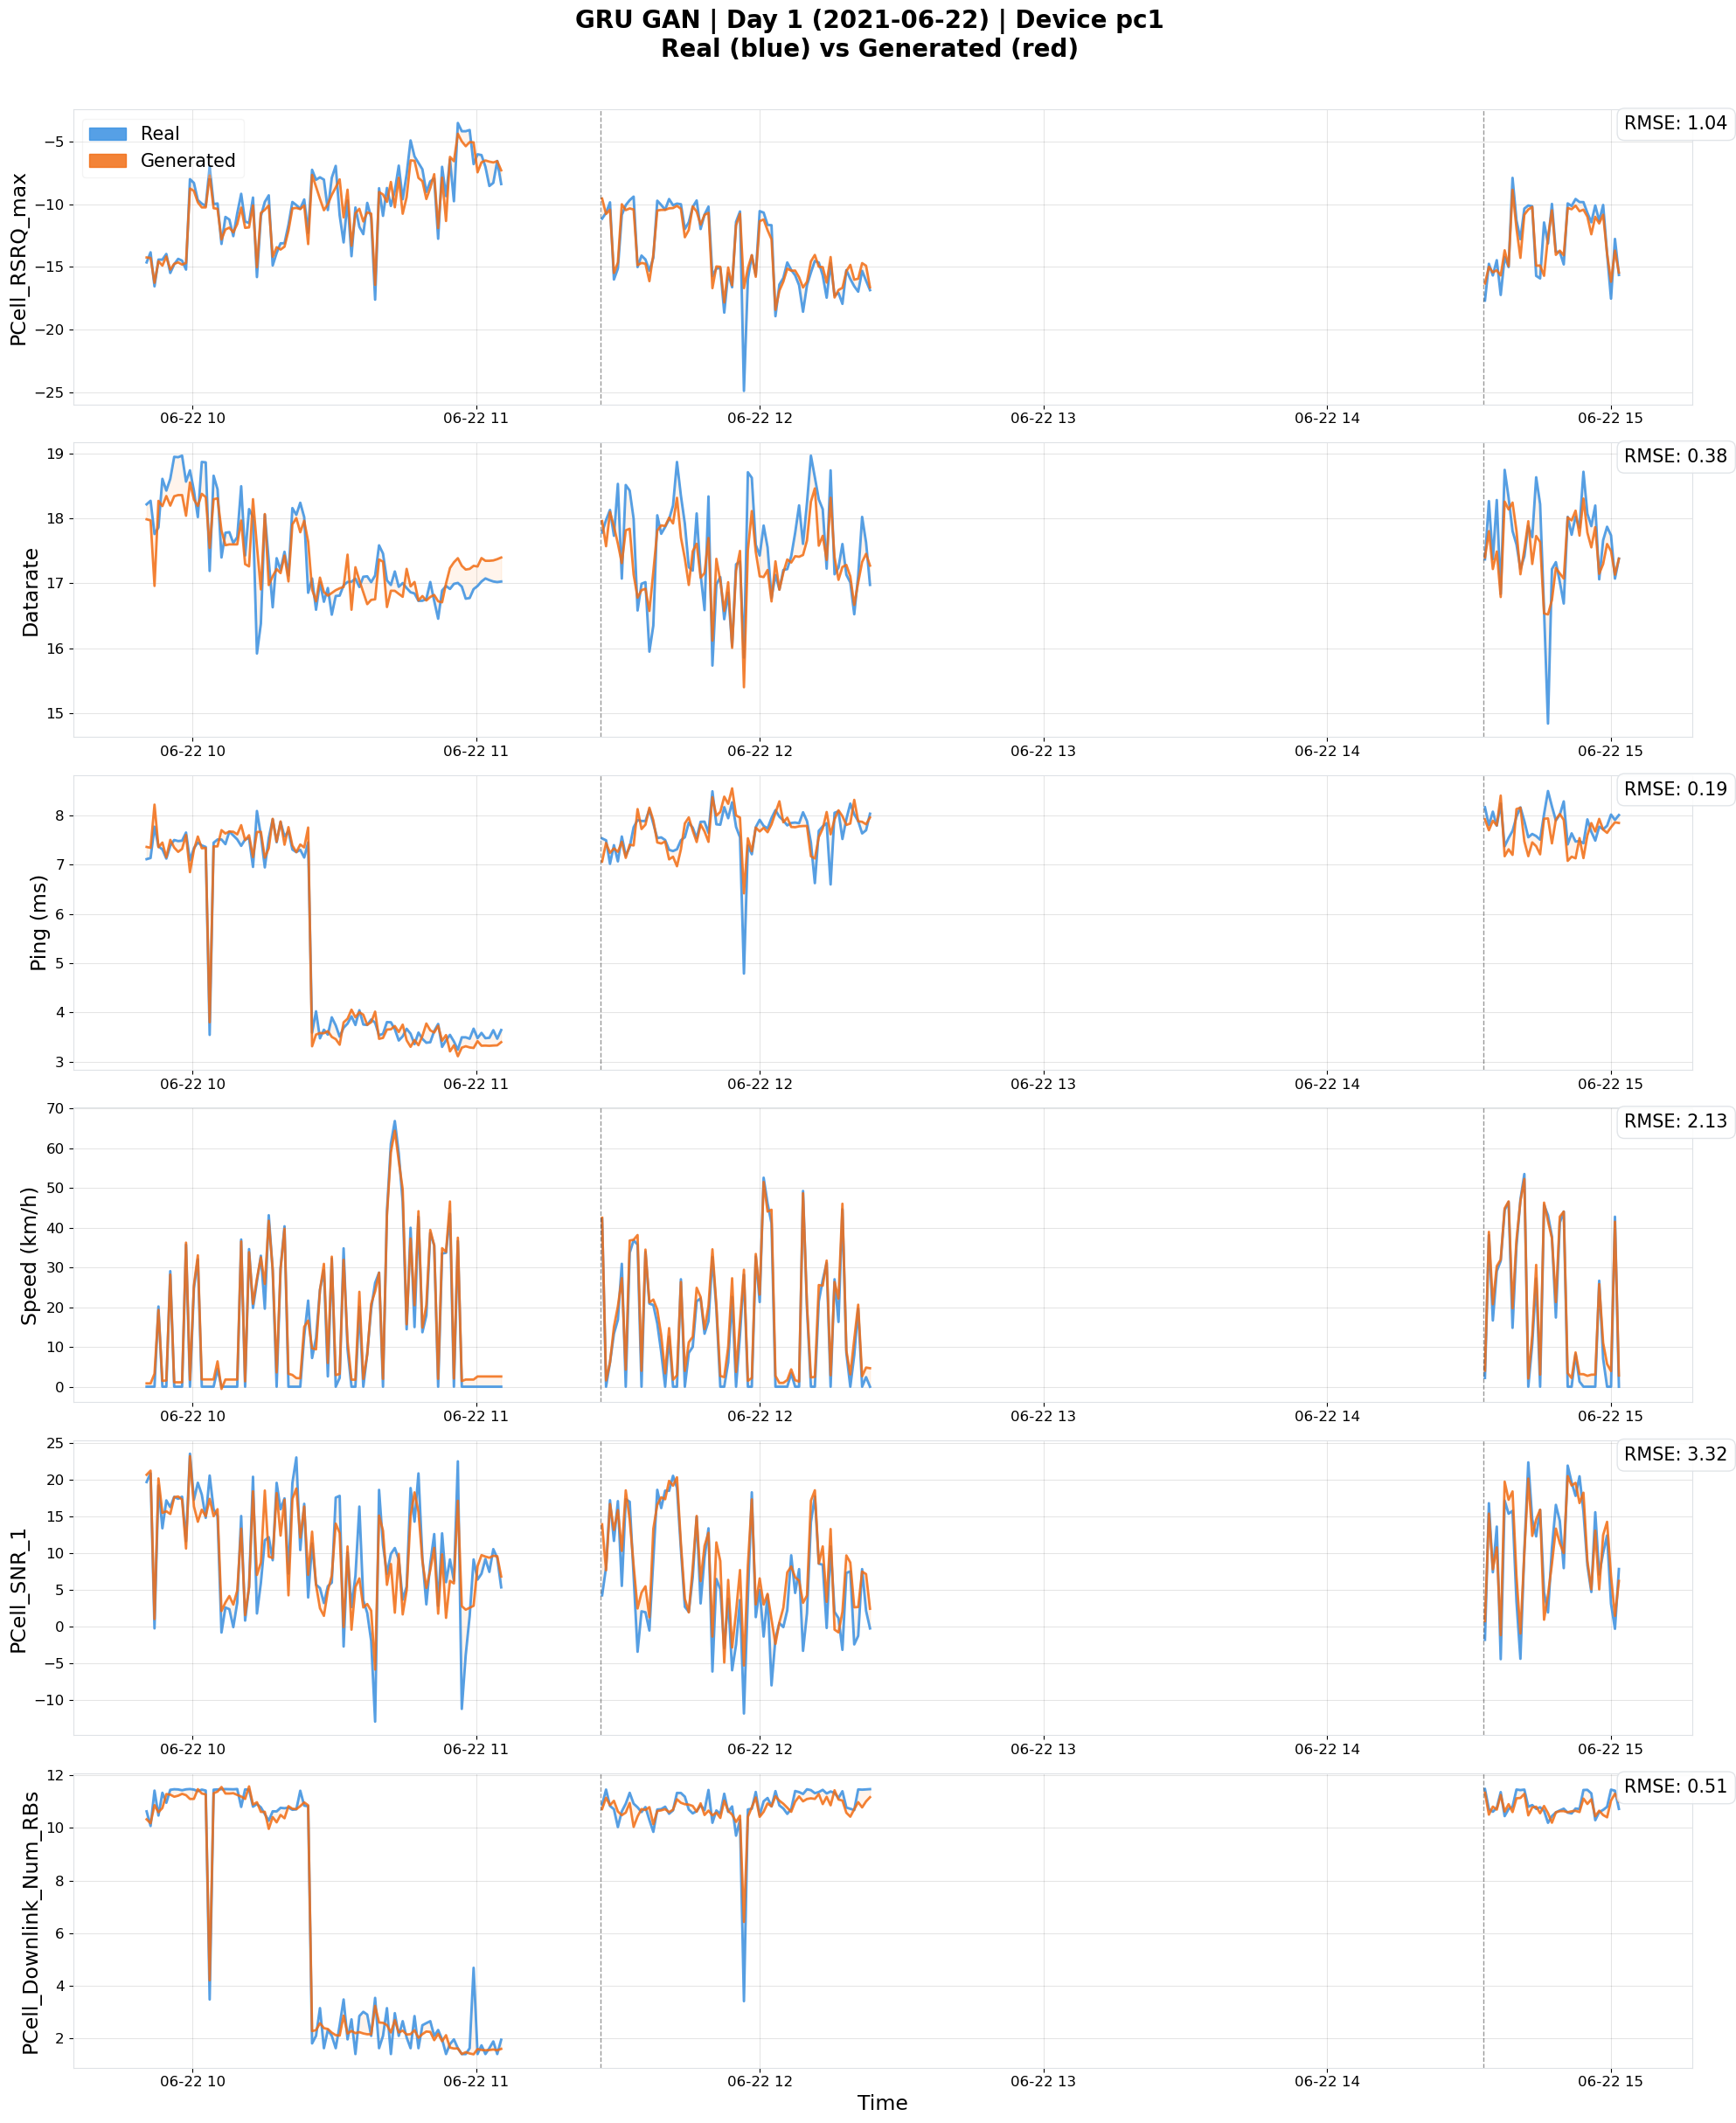


Summary — pc1 Day 1:
  PCell_RSRQ_max       RMSE:    1.096  MAE:    0.750  Corr:  0.952
  Datarate             RMSE:    0.408  MAE:    0.311  Corr:  0.847
  Ping (ms)            RMSE:    0.256  MAE:    0.185  Corr:  0.990
  Speed (km/h)         RMSE:    2.383  MAE:    2.007  Corr:  0.996
  PCell_SNR_1          RMSE:    3.176  MAE:    2.430  Corr:  0.921
  PCell_Downlink_Num_RBs RMSE:    0.460  MAE:    0.294  Corr:  0.993


In [ ]:
gen_points = plot_day_comparison('pc1', day_index=0, gen_every=50)

In [ ]:
def find_gaps(device_id, day_index=0, min_gap_sec=60, max_gap_sec=14400):
    """Find all gaps for a device on a specific day."""
    device_col = f'device_{device_id}'
    device_data = df[df[device_col] == 1].sort_values('timestamp').reset_index(drop=True)
    dates = sorted(device_data['timestamp'].dt.date.unique())

    if day_index >= len(dates):
        print(f"Only {len(dates)} days available")
        return None, None, None

    day_date = dates[day_index]
    day = device_data[device_data['timestamp'].dt.date == day_date].reset_index(drop=True)

    print(f"Device {device_id} — Day {day_index+1} ({day_date})")
    print(f"Total rows: {len(day)}")
    print(f"Time range: {day['timestamp'].iloc[0]} → {day['timestamp'].iloc[-1]}")

    # Find gaps
    deltas = day['timestamp'].diff().dt.total_seconds()
    gaps = []

    for idx in deltas[deltas > min_gap_sec].index:
        gap_sec = deltas[idx]
        if gap_sec > max_gap_sec:
            continue

        before_row = day.iloc[idx - 1]
        after_row = day.iloc[idx]

        gaps.append({
            'gap_id': len(gaps),
            'gap_start': before_row['timestamp'],
            'gap_end': after_row['timestamp'],
            'duration_sec': int(gap_sec),
            'duration_min': gap_sec / 60,
            'before_idx': idx - 1,
            'after_idx': idx,
            'before_lat': before_row['Latitude'],
            'before_lon': before_row['Longitude'],
            'before_speed': before_row['speed_kmh'],
            'after_lat': after_row['Latitude'],
            'after_lon': after_row['Longitude'],
            'after_speed': after_row['speed_kmh'],
        })

    # Print gap table
    print(f"\nFound {len(gaps)} gaps (>{min_gap_sec}s, <{max_gap_sec}s):\n")
    print(f"  {'ID':>4} {'Start':>22} {'End':>22} {'Duration':>10} {'Before Speed':>14} {'After Speed':>13}")
    print(f"  {'─'*90}")
    for g in gaps:
        print(f"  {g['gap_id']:>4} "
              f"{str(g['gap_start'])[:22]:>22} "
              f"{str(g['gap_end'])[:22]:>22} "
              f"{g['duration_sec']:>7}s ({g['duration_min']:.1f}m) "
              f"{g['before_speed']:>10.1f} km/h "
              f"{g['after_speed']:>10.1f} km/h")

    # Find segments
    seg_gaps = day['timestamp'].diff().dt.total_seconds()
    break_points = seg_gaps[seg_gaps > min_gap_sec].index.tolist()
    starts = [0] + break_points
    ends = break_points + [len(day)]


    return day, gaps, day_date


In [ ]:
day_data, gaps, day_date = find_gaps('pc1', day_index=0)

Device pc1 — Day 1 (2021-06-22)
Total rows: 19607
Time range: 2021-06-22 09:49:54+02:00 → 2021-06-22 18:13:59+02:00

Found 5 gaps (>60s, <14400s):

    ID                  Start                    End   Duration   Before Speed   After Speed
  ──────────────────────────────────────────────────────────────────────────────────────────
     0 2021-06-22 11:06:00+02 2021-06-22 11:26:15+02    1215s (20.2m)        0.0 km/h       48.2 km/h
     1 2021-06-22 12:23:59+02 2021-06-22 14:33:00+02    7741s (129.0m)        0.0 km/h        7.8 km/h
     2 2021-06-22 15:44:59+02 2021-06-22 15:56:30+02     691s (11.5m)        0.0 km/h        0.0 km/h
     3 2021-06-22 16:26:04+02 2021-06-22 16:33:46+02     462s (7.7m)       22.0 km/h        0.0 km/h
     4 2021-06-22 17:16:59+02 2021-06-22 17:24:58+02     479s (8.0m)        0.0 km/h       47.0 km/h


In [ ]:
def style_ax(ax):
    ax.set_facecolor(CARD)
    ax.tick_params(colors=TEXT, labelsize=12)
    for sp in ax.spines.values():
        sp.set_edgecolor(BORDER)
    ax.grid(True, alpha=0.1, color=TEXT)

In [ ]:
BG = '#ffffff'    
CARD = '#ffffff'     
BORDER = '#dee2e6'   
TEXT = "#000000"    
MUTED = "#d0841b"    
MUT = '#6c757d'    
GREEN  = '#2ca02c'    
BLUE = "#3890E2"      
ORANGE = '#ff7f0e' 

In [ ]:

def fill_gap(device_id, day_data, gap, context_before=400, context_after=50):
    """Fill a specific gap using generate_chain."""
    print(f"\nFilling Gap {gap['gap_id']}:")
    print(f"  Start: {gap['gap_start']}")
    print(f"  End:   {gap['gap_end']}")
    print(f"  Duration: {gap['duration_sec']}s ({gap['duration_min']:.1f} min)")

    start_ts = gap['gap_start'] + pd.Timedelta(seconds=1)
    n_steps = gap['duration_sec'] - 1

    if n_steps > 3600:
        print(f"  Gap too long ({n_steps}s). Limiting to 3600s.")
        n_steps = 3600

    print(f"  Generating {n_steps} timesteps...")

    gen = generate_chain(
        device_id, str(start_ts), n_steps=n_steps,
        mode='with_gps',
        lat=gap['before_lat'], lon=gap['before_lon']
    )

    if gen is None:
        print("  Generation failed!")
        return None

    print(f"  Generated {len(gen)} rows")

    # Get context: real data before and after gap
    before_start = max(0, gap['before_idx'] - context_before)
    before = day_data.iloc[before_start:gap['before_idx'] + 1]

    after_end = min(len(day_data), gap['after_idx'] + context_after)
    after = day_data.iloc[gap['after_idx']:after_end]

    result = {
        'gap': gap,
        'generated': gen,
        'before': before,
        'after': after,
    }

    return result

In [ ]:


def plot_filled_gap(fill_result, features=None, show_before=400, show_after=50):
    """Fill Data gaps using Synthetic Data"""
    if fill_result is None:
        print("No fill result to plot")
        return

    gap = fill_result['gap']
    gen = fill_result['generated']
    before = fill_result['before'].tail(show_before)
    after = fill_result['after'].head(show_after)


    if features is None:
        features = [
            ('datarate', 'Datarate'),
            ('PCell_RSRQ_max', 'PCell_RSRQ_max'),
            ('ping_ms', 'Ping (ms)'),
            ('PCell_SNR_2', 'PCell_SNR_2'),
            ('PCell_RSSI_max', 'PCell_RSSI_max'),
        ]

    n_before = len(before)
    n_gen = len(gen)
    n_after = len(after)

    fig, axes = plt.subplots(len(features), 1,
                             figsize=(20, 3.5 * len(features)),
                             facecolor=BG)
    fig.suptitle(
        f'Device - PC1  | '
        f'{str(gap["gap_start"])[:19]} → {str(gap["gap_end"])[:19]} | '
        f'{gap["duration_sec"]}s ({gap["duration_min"]:.1f} min)\n'
        f'Before: {n_before} rows | Generated: {n_gen} rows | After: {n_after} rows',
        color=TEXT, fontsize=20, fontweight='bold', y=1.02
    )
    
    for i, (col, label) in enumerate(features):
        ax = axes[i]
        style_ax(ax)

        # Build continuous x-axis using timestamps
        before_ts = before['timestamp'].apply(
            lambda x: pd.Timestamp(x).tz_localize(None)).values
        gen_ts = gen['timestamp'].apply(
            lambda x: pd.Timestamp(x).tz_localize(None)).values
        after_ts = after['timestamp'].apply(
            lambda x: pd.Timestamp(x).tz_localize(None)).values

        # Real before
        if col in before.columns:
            ax.plot(before_ts, before[col].values,
                    color=BLUE, linewidth=1.5, alpha=0.9, label='Real')

        # Synthetic fill
        if col in gen.columns:
            ax.plot(gen_ts, gen[col].values,
                    color=ORANGE, linewidth=1.2, linestyle='--',
                    alpha=0.9, label='Synthetic Fill')

        # Real after
        if col in after.columns:
            ax.plot(after_ts, after[col].values,
                    color=BLUE, linewidth=1.5, alpha=0.9)

        # Highlight gap region
        gap_start_naive = pd.Timestamp(gap['gap_start']).tz_localize(None)
        gap_end_naive = pd.Timestamp(gap['gap_end']).tz_localize(None)
        ax.axvspan(gap_start_naive, gap_end_naive, color=MUTED, alpha=0.07)
        ax.axvline(gap_start_naive, color=MUTED, linewidth=1, linestyle=':', alpha=0.7)
        ax.axvline(gap_end_naive, color=MUTED, linewidth=1, linestyle=':', alpha=0.7)

        # Transition markers
        if col in before.columns and col in gen.columns and len(gen) > 0:
            last_real = before[col].iloc[-1]
            first_gen = gen[col].iloc[0]
            jump = abs(first_gen - last_real)
            

        if col in after.columns and col in gen.columns and len(gen) > 0:
            last_gen = gen[col].iloc[-1]
            first_after = after[col].iloc[0]
            jump = abs(first_after - last_gen)
            

        ax.set_ylabel(label, color=TEXT, fontsize=17)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

        if i == 0:
            real_patch = mpatches.Patch(color=BLUE, alpha=0.9, label='Real Data')
            syn_patch = mpatches.Patch(color=ORANGE, alpha=0.9, label='Synthetic Fill')
            gap_patch = mpatches.Patch(color=MUTED, alpha=0.2, label='Gap Region')
            ax.legend(handles=[real_patch, syn_patch, gap_patch],
                     framealpha=0.2, labelcolor=TEXT, fontsize=15, loc='upper left')

    axes[-1].set_xlabel('Time', color=TEXT, fontsize=17)
    
    plt.tight_layout()
    plt.savefig(f'Gap_fill.png', dpi=300,
                facecolor=BG, bbox_inches='tight')
    plt.show()

    # Print stats
    print(f"\nGap Fill Statistics:")
    for col, label in features:
        if col in before.columns and col in gen.columns and col in after.columns:
            before_mean = before[col].iloc[-5:].mean()
            gen_mean = gen[col].mean()
            after_mean = after[col].iloc[:5].mean()
            gen_std = gen[col].std()

            print(f"  {label:<20} "
                  f"Before(last 5): {before_mean:>8.2f} | "
                  f"Generated mean: {gen_mean:>8.2f} (std: {gen_std:.2f}) | "
                  f"After(first 5): {after_mean:>8.2f}")



Filling Gap 3:
  Start: 2021-06-22 16:26:04+02:00
  End:   2021-06-22 16:33:46+02:00
  Duration: 462s (7.7 min)
  Generating 461 timesteps...
  Generated 461 rows


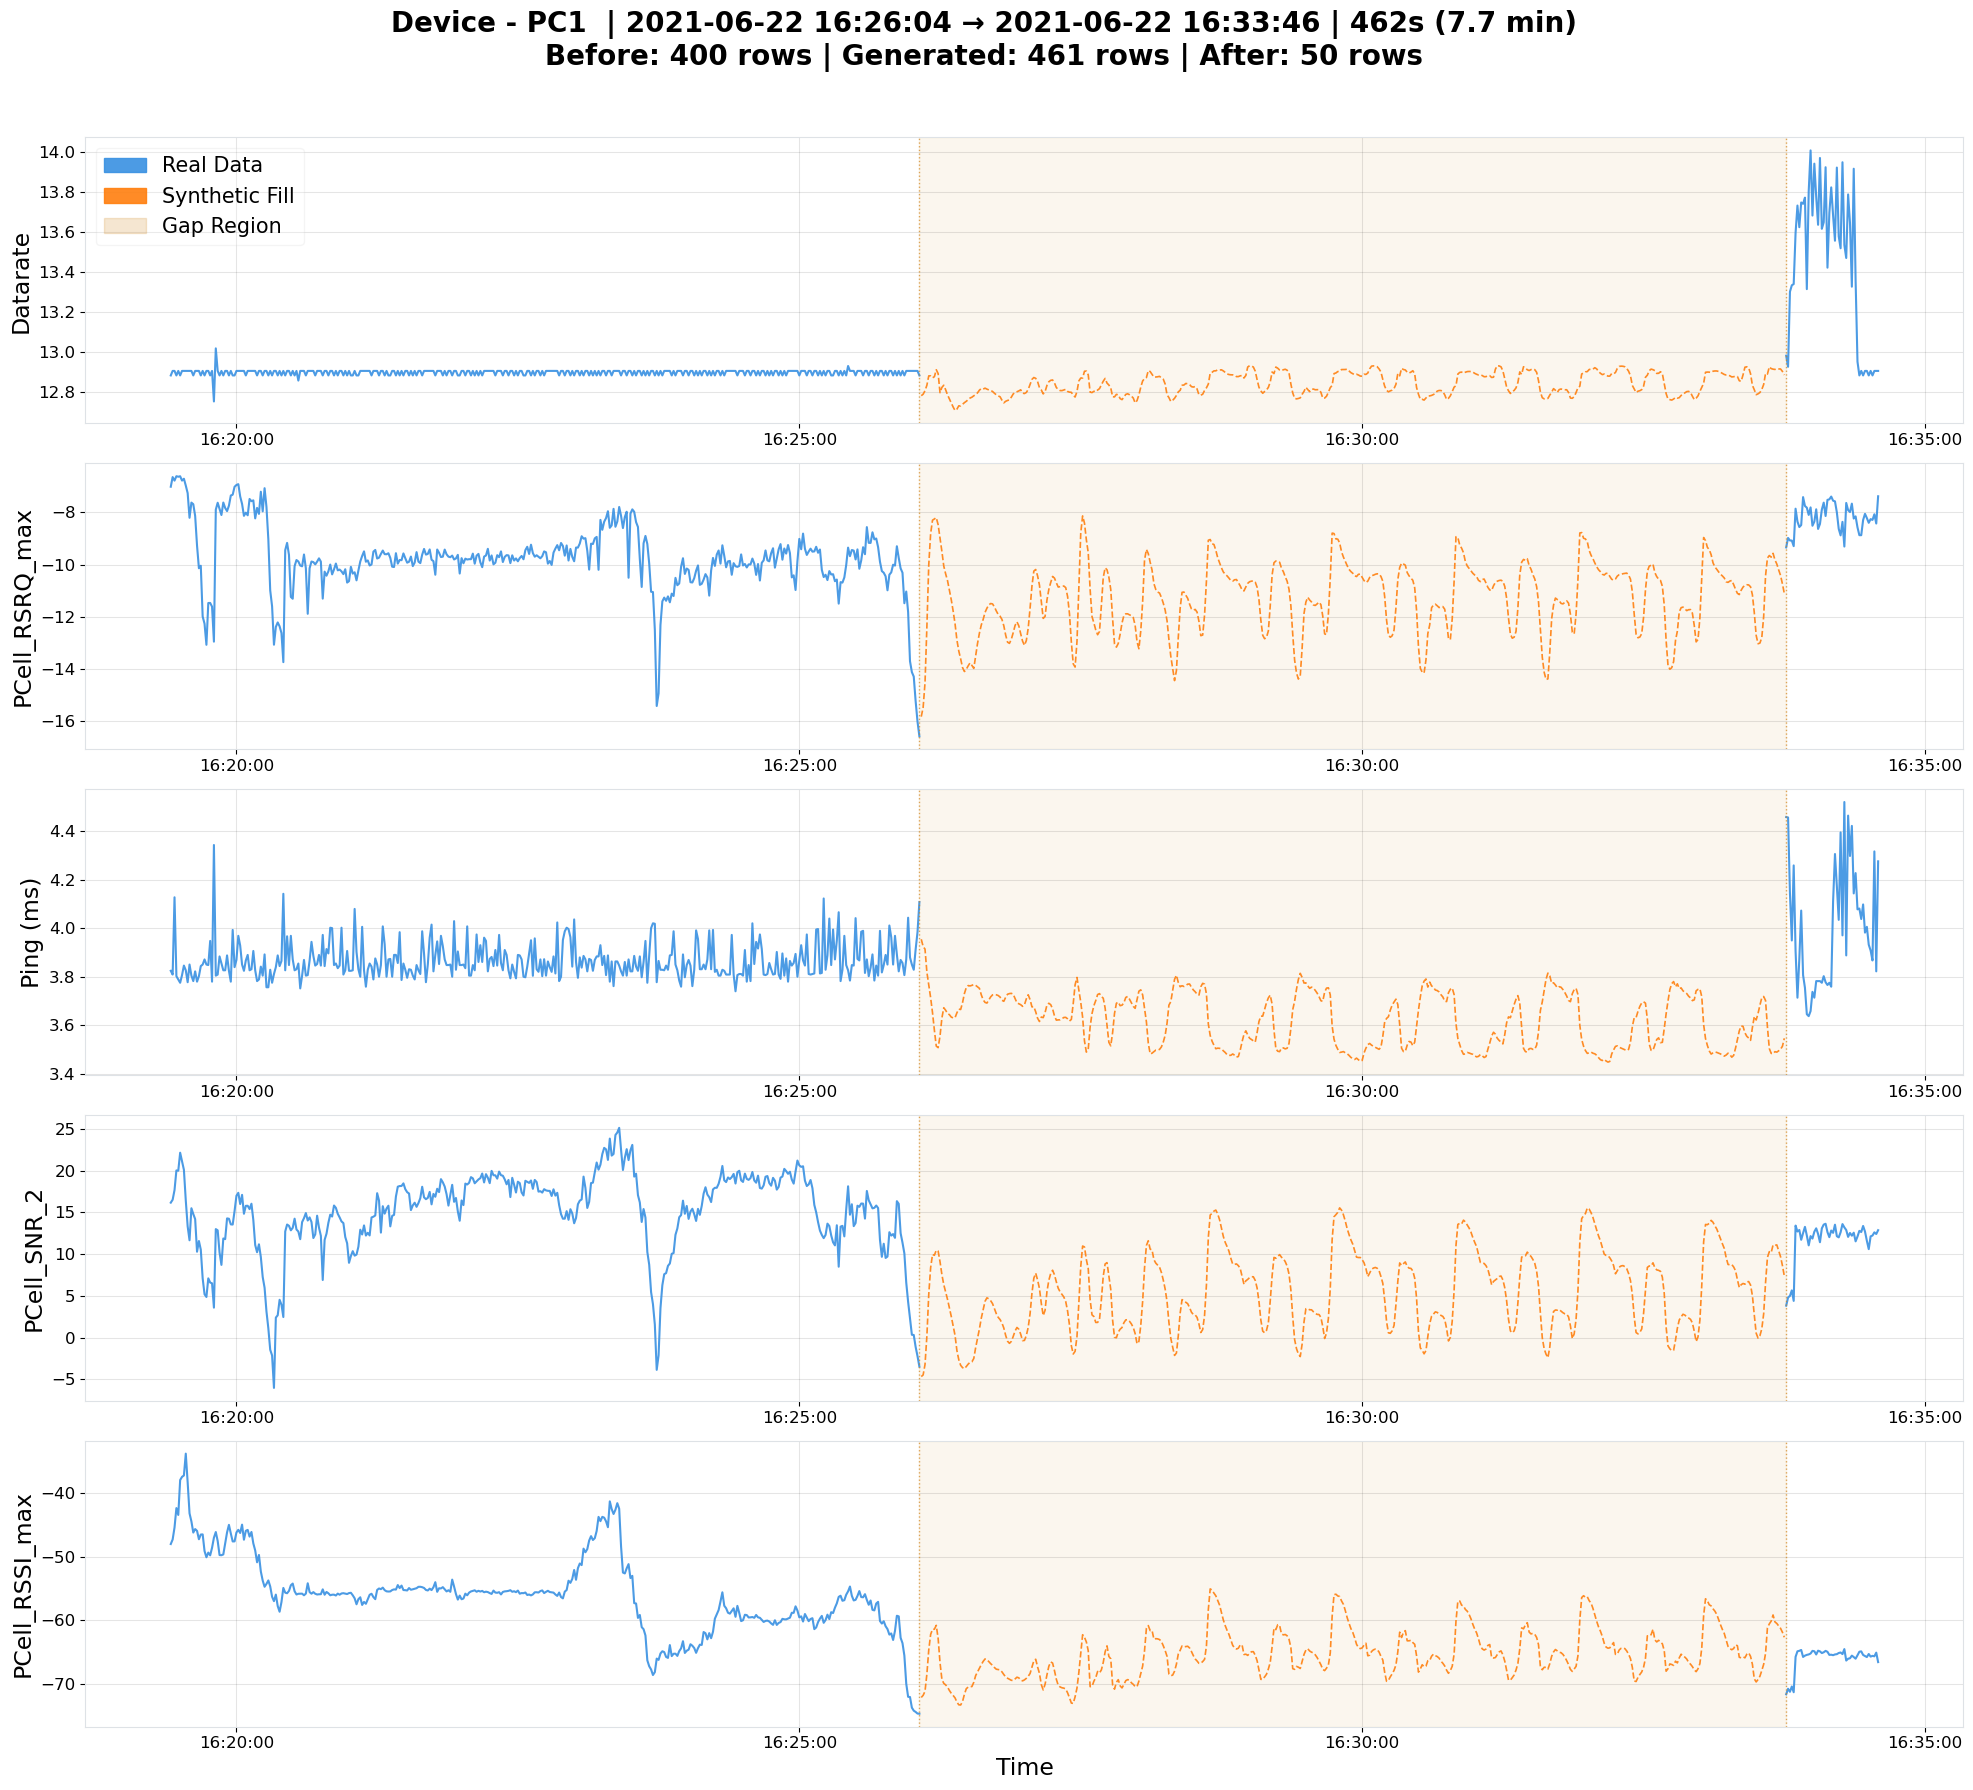


Gap Fill Statistics:
  Datarate             Before(last 5):    12.90 | Generated mean:    12.84 (std: 0.05) | After(first 5):    13.18
  PCell_RSRQ_max       Before(last 5):   -15.26 | Generated mean:   -11.27 (std: 1.36) | After(first 5):    -9.15
  Ping (ms)            Before(last 5):     3.94 | Generated mean:     3.62 (std: 0.11) | After(first 5):     4.25
  PCell_SNR_2          Before(last 5):    -1.24 | Generated mean:     5.56 (std: 4.71) | After(first 5):     4.73
  PCell_RSSI_max       Before(last 5):   -74.42 | Generated mean:   -65.33 (std: 3.78) | After(first 5):   -71.14


In [ ]:
result = fill_gap('pc1', day_data, gaps[3])
plot_filled_gap(result)

In [ ]:
def fill_and_show(device_id, day_data, gap, day_index=0):

    
    device_col = f'device_{device_id}'
    device_data = df[df[device_col] == 1].sort_values('timestamp').reset_index(drop=True)
    
    # Context
    before = day_data.iloc[max(0, gap['before_idx'] - 4):gap['before_idx'] + 1] 
    after = day_data.iloc[gap['after_idx']:gap['after_idx'] + 5] 
    
    # Generate
    start_ts = gap['gap_start'] + pd.Timedelta(seconds=1)
    n_steps = min(gap['duration_sec'] - 1, 3600)
    
    start_lat = before['Latitude'].iloc[-1]
    start_lon = before['Longitude'].iloc[-1]
    
    print(f"Filling Gap {gap['gap_id']}: {n_steps} steps")
    print(f"  Start: ({start_lat:.4f}, {start_lon:.4f}) | Timestamp: {start_ts}")
    
    gen = generate_chain(
        device_id, str(start_ts), n_steps=n_steps,
        mode='with_gps',
        lat=start_lat, lon=start_lon
    )
    
    if gen is None or len(gen) == 0:
        print("Generation failed!")
        return
    
    # Tag source
    before = before.copy()
    gen = gen.copy()
    after = after.copy()
    
    before['source'] = 'REAL_BEFORE'
    gen['source'] = 'GENERATED'
    after['source'] = 'REAL_AFTER'
    
   
    # Combine and save to Excel

    combined = pd.concat([before, gen, after], ignore_index=True)

    for col in combined.columns:
        if hasattr(combined[col], 'dt') and hasattr(combined[col].dt, 'tz') and combined[col].dt.tz is not None:
            combined[col] = combined[col].dt.tz_localize(None)
    
    if hasattr(combined.index, 'tz') and combined.index.tz is not None:
        combined.index = combined.index.tz_localize(None)



    return combined




In [ ]:

day_data, gaps, day_date = find_gaps('pc1', day_index=0)

sorted_gaps = sorted(gaps, key=lambda g: g['duration_sec'])
print(f"Shortest gap: Gap {sorted_gaps[0]['gap_id']} — {sorted_gaps[0]['duration_sec']}s\n")

result = fill_and_show('pc1', day_data, sorted_gaps[0], day_index=0)

Device pc1 — Day 1 (2021-06-22)
Total rows: 19607
Time range: 2021-06-22 09:49:54+02:00 → 2021-06-22 18:13:59+02:00

Found 5 gaps (>60s, <14400s):

    ID                  Start                    End   Duration   Before Speed   After Speed
  ──────────────────────────────────────────────────────────────────────────────────────────
     0 2021-06-22 11:06:00+02 2021-06-22 11:26:15+02    1215s (20.2m)        0.0 km/h       48.2 km/h
     1 2021-06-22 12:23:59+02 2021-06-22 14:33:00+02    7741s (129.0m)        0.0 km/h        7.8 km/h
     2 2021-06-22 15:44:59+02 2021-06-22 15:56:30+02     691s (11.5m)        0.0 km/h        0.0 km/h
     3 2021-06-22 16:26:04+02 2021-06-22 16:33:46+02     462s (7.7m)       22.0 km/h        0.0 km/h
     4 2021-06-22 17:16:59+02 2021-06-22 17:24:58+02     479s (8.0m)        0.0 km/h       47.0 km/h
Shortest gap: Gap 3 — 462s

Filling Gap 3: 461 steps
  Start: (52.4970, 13.3066) | Timestamp: 2021-06-22 16:26:05+02:00


In [ ]:
result[['source', 'timestamp','ping_ms', 'datarate', 'jitter', 'Latitude', 'Longitude', 'speed_kmh', 'Altitude', 'PCell_freq_MHz', 'PCell_RSRP_max', 'PCell_RSRQ_max', 'PCell_SNR_1', 'PCell_SNR_2']].head(20)


,source,timestamp,ping_ms,datarate,jitter,Latitude,Longitude,speed_kmh,Altitude,PCell_freq_MHz,PCell_RSRP_max,PCell_RSRQ_max,PCell_SNR_1,PCell_SNR_2
0,REAL_BEFORE,2021-06-22 15:24:16+02:00,3.363842,12.906694,0.001850,52.494783,13.284510,7.963600,40.620567,1800.0,-102.115000,-8.340000,14.744000,13.987000
1,REAL_BEFORE,2021-06-22 15:24:17+02:00,3.520461,12.884109,0.002223,52.494787,13.284478,7.963600,40.778759,1800.0,-103.018125,-7.792500,15.865000,15.025000
2,REAL_BEFORE,2021-06-22 15:24:18+02:00,3.424263,12.906694,0.000852,52.494792,13.284447,7.963600,40.897118,1800.0,-102.300000,-7.285000,16.364000,15.998000
3,REAL_BEFORE,2021-06-22 15:24:19+02:00,3.414443,12.906694,0.003997,52.494795,13.284415,7.963600,40.816334,1800.0,-103.661250,-7.782500,14.956000,14.469000
4,REAL_BEFORE,2021-06-22 15:24:20+02:00,3.356897,12.884109,0.003085,52.494800,13.284383,7.963600,40.624329,1800.0,-104.180625,-8.243750,13.361000,13.484000
5,GENERATED,2021-06-22 15:24:21+02:00,3.436822,12.897082,-0.009049,52.500099,13.293247,10.455299,40.629650,1800.0,-97.802391,-8.404482,13.874453,10.379644
6,GENERATED,2021-06-22 15:24:22+02:00,3.443249,12.904645,-0.009550,52.500313,13.293062,17.218351,39.821613,1800.0,-97.048752,-8.367894,14.180336,10.502571
7,GENERATED,2021-06-22 15:24:23+02:00,3.443998,12.901209,-0.009358,52.500614,13.292522,22.923580,38.575375,1800.0,-97.336548,-8.563066,13.973557,10.189466
8,GENERATED,2021-06-22 15:24:24+02:00,3.452775,12.903050,-0.009073,52.501041,13.291272,28.551100,37.493011,1800.0,-97.237801,-8.733849,13.983590,10.038345
9,GENERATED,2021-06-22 15:24:25+02:00,3.444844,12.903995,-0.009422,52.501671,13.288976,33.427681,37.422405,1800.0,-97.424530,-8.753228,13.678570,9.646057
